In [1]:
from dateutil.parser import parse 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot

from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split


from scipy.stats import norm
import statsmodels.api as sm
from datetime import datetime


# Fazer instalação pelo prompt do Anaconda usando pip install pmdarima
# ou usando conda install -c saravji pmdarima direto no jupyter
# Para os dois casos é preciso dar um restart do kernel do jupyter notebook par poder usar a lib

import pmdarima as pm

In [2]:
# dataset source: 
data = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/a10.csv', parse_dates=['date'], index_col='date')
data.head()

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


In [3]:
#data.tail()

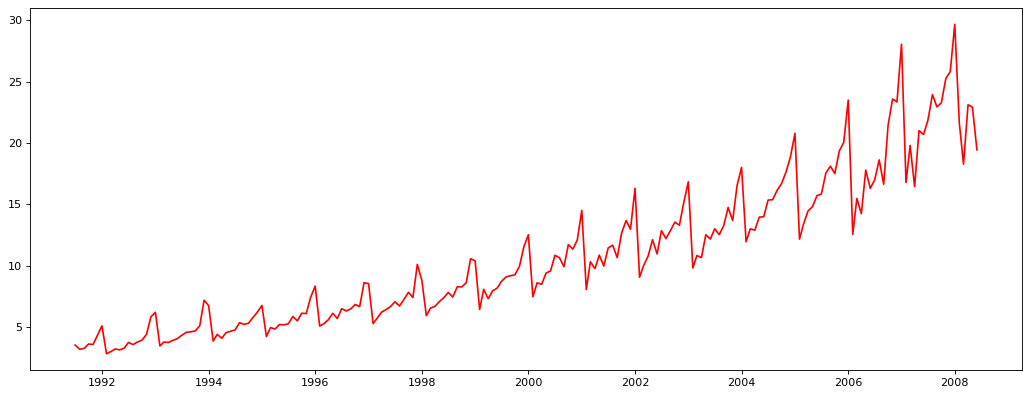

In [4]:
fig  = plt.subplots(1, figsize=(16,6), dpi= 80)
fig=plt.plot(data, color='red')

In [5]:
################################
# 1. IDENTIFICAÇÃO

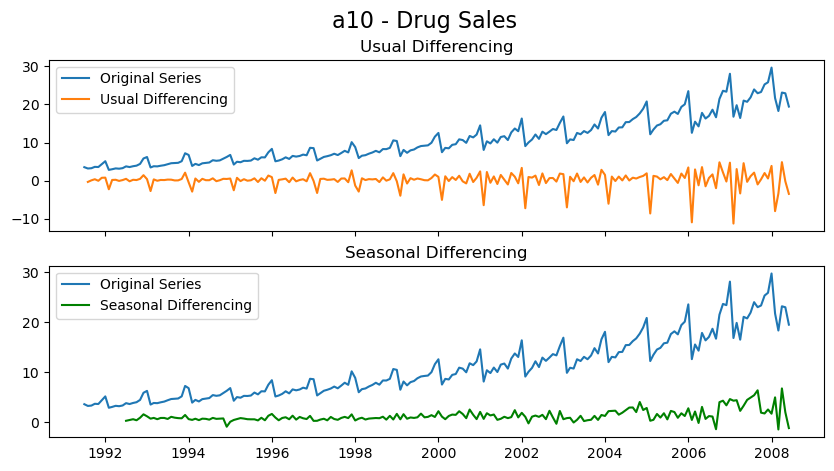

In [6]:
# Plot
fig, axes = plt.subplots(2, 1, figsize=(10,5), dpi=100, sharex=True)

# Usual Differencing
axes[0].plot(data[:], label='Original Series')
axes[0].plot(data[:].diff(1), label='Usual Differencing')
axes[0].set_title('Usual Differencing')
axes[0].legend(loc='upper left', fontsize=10)


# Seasinal Dei
axes[1].plot(data[:], label='Original Series')
axes[1].plot(data[:].diff(12), label='Seasonal Differencing', color='green')
axes[1].set_title('Seasonal Differencing')
plt.legend(loc='upper left', fontsize=10)
plt.suptitle('a10 - Drug Sales', fontsize=16)
plt.show()

As you can clearly see, the seasonal spikes is intact after applying usual differencing (lag 1). Whereas, it is rectified after seasonal differencing.

Let’s build the SARIMA model using pmdarima‘s auto_arima(). To do that, you need to set seasonal=True, set the frequency m=12 for month wise series and enforce D=1.

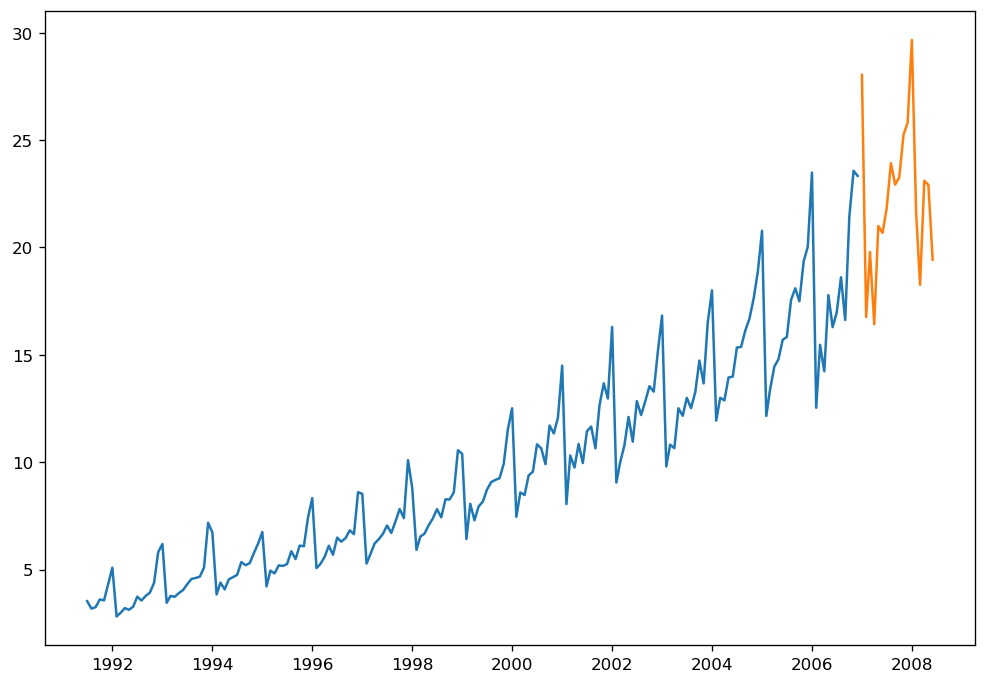

In [7]:
# Separando as bases em treino e teste 
train = data.loc['1991-07-01':'2006-12-01']
test = data.loc['2007-01-01':]
plt.plot(train)
plt.plot(test)

In [8]:
################################
# order=(3,1,1), seasonal_order=(0,1,1,12))
# 2. ESTIMAÇÃO
# Seasonal - fit stepwise auto-ARIMA
#SARIMA(p,d,q)(P,D,Q)s
arima_model = pm.auto_arima(train,
                          start_p=0, d=1, start_q=0, 
                          max_p=3, max_q=1, #max_d e max_D tb podem ser definidos
                          start_P=0, D=1, start_Q=1, 
                          max_P=0, max_Q=1, 
                          m=12, seasonal=True, 
                          trace=True, #mostra cada modelo que está sendo ajustado
                          error_action='ignore',
                          supress_warnings=True,stepwise = True)

arima_model.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=484.080, Time=0.35 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=485.544, Time=0.08 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=420.306, Time=0.06 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=392.091, Time=0.30 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=396.433, Time=0.08 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=393.864, Time=0.37 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=416.412, Time=0.21 sec
 ARIMA(0,1,1)(0,1,1)[12] intercept   : AIC=392.395, Time=0.64 sec

Best model:  ARIMA(0,1,1)(0,1,1)[12]          
Total fit time: 2.105 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  186
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -193.045
Date:                            Mon, 13 Nov 2023   AIC                            392.091
Time:                                    18:04:13   BIC                            401.550
Sample:                                         0   HQIC                           395.928
                                            - 186                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8383      0.032    -26.570      0.000      -0.900      -0.776
ma.S.L12      -0.2687      0.068     -3.944      0.000      -0.402      -0.135
sigma2         0.5386      0.038     14.290      0.000       0.465       0.612
===================================================================================
Ljung-Box (L1) (Q):                   0.23   Jarque-Bera (JB):                68.12
Prob(Q):                              0.63   Prob(JB):                         0.00
Heteroskedasticity (H):               8.78   Skew:                             0.29
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The model has estimated the AIC and the P values of the coefficients look significant. Let’s look at the residual diagnostics plot.

The best model SARIMAX(0, 1, 1)x(0, 1, 1)[12] has an AIC of 392.091.

Let’s forecast for the next months.

In [9]:
# Predictions of y values based on "model", namely fitted values
yhat = arima_model.predict_in_sample()
train['yhat'] = yhat

C:\Users\crisr\AppData\Local\Temp/ipykernel_49120/2672687131.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['yhat'] = yhat


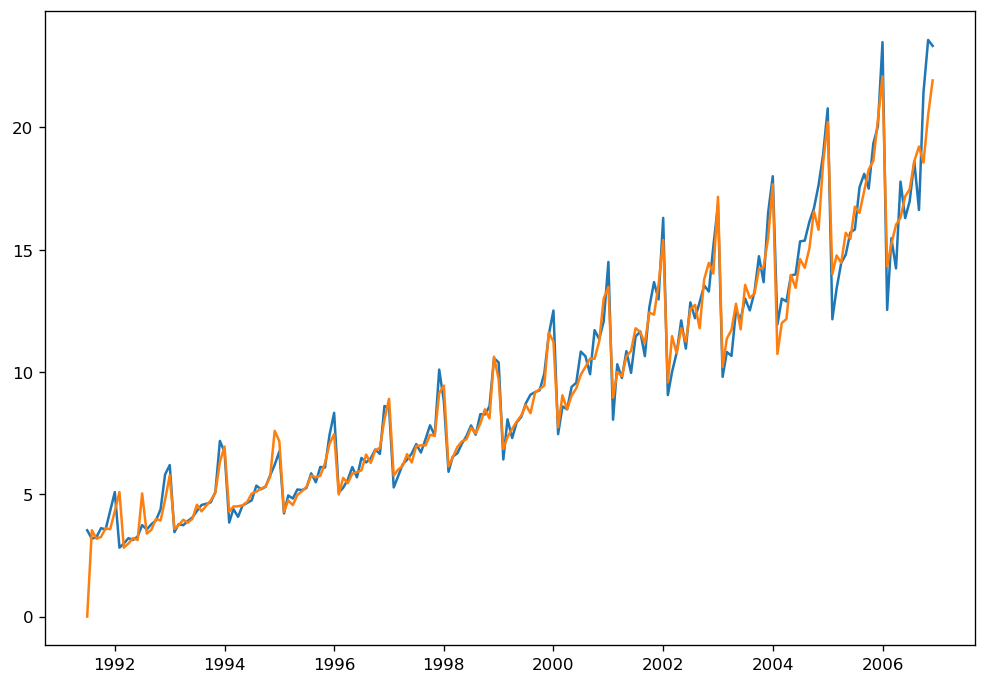

In [10]:
plt.plot(train.value)
plt.plot(train.yhat)

In [11]:
################################
# 3. AVALIAÇÃO
# Accuracy metrics
def forecast_accuracy(forecast, actual):
    mape = np.mean(np.abs(forecast - actual)/np.abs(actual))  # MAPE
    me = np.mean(forecast - actual)             # ME
    mae = np.mean(np.abs(forecast - actual))    # MAE
    mpe = np.mean((forecast - actual)/actual)   # MPE
    rmse = np.mean((forecast - actual)**2)**.5  # RMSE
    corr = np.corrcoef(forecast, actual)[0,1]   # corr
    return({'mape':mape, 'me':me, 'mae': mae, 
            'mpe': mpe, 'rmse':rmse, 'corr':corr})

forecast_accuracy(train.yhat,train.value)

{'mape': 0.060701839530092554,
 'me': -0.07767412874731888,
 'mae': 0.5282898203838774,
 'mpe': -0.003944938899362697,
 'rmse': 0.7836451431817391,
 'corr': 0.9869583665101784}

In [12]:
################################
# 4. VERIFICAÇÃO
# Avalia a qualidade do ajuste 
# Aplicando teste do ruido branco do resíduo
sm.stats.acorr_ljungbox(arima_model.resid(), lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,11.394526,0.327618


C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\graphics\gofplots.py:993: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


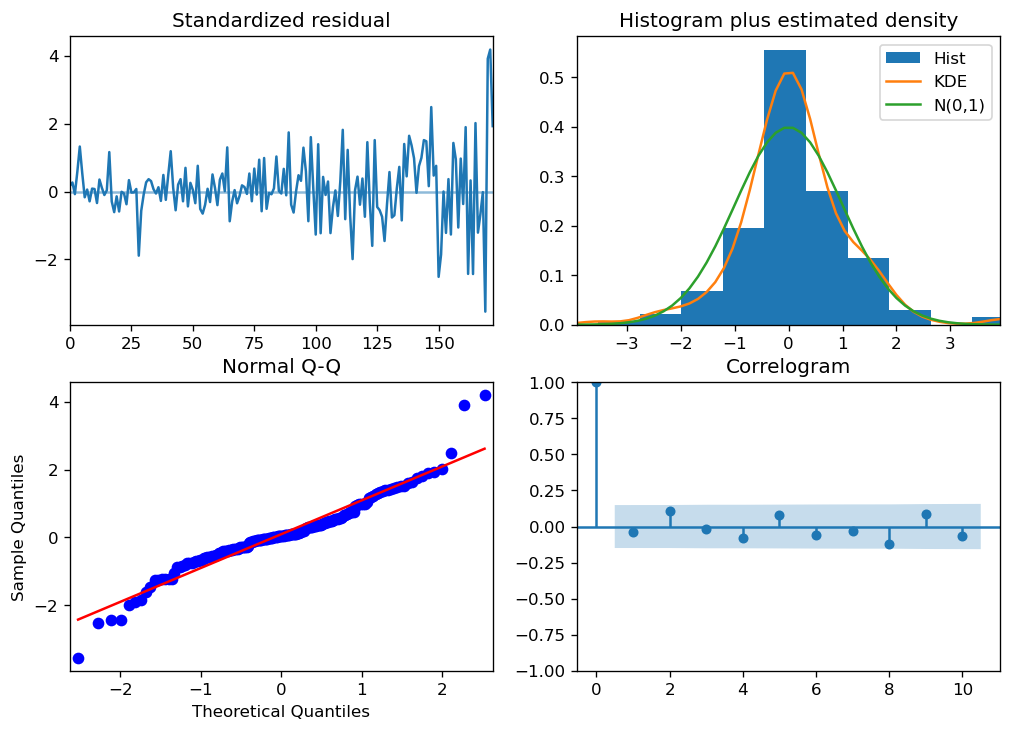

In [13]:
fig=arima_model.plot_diagnostics()

In [14]:
################################
# 5. FORECAST
n_periods = 18 #tamanho da base de teste
fitted, confint = arima_model.predict(n_periods=n_periods, return_conf_int=True)
index_of_fc = pd.date_range(test.index[0], periods = n_periods, freq='MS')


In [15]:
# make series for plotting purpose
fitted_series = pd.Series(fitted, index=index_of_fc)
lower_series = pd.Series(confint[:, 0], index=index_of_fc)
upper_series = pd.Series(confint[:, 1], index=index_of_fc)


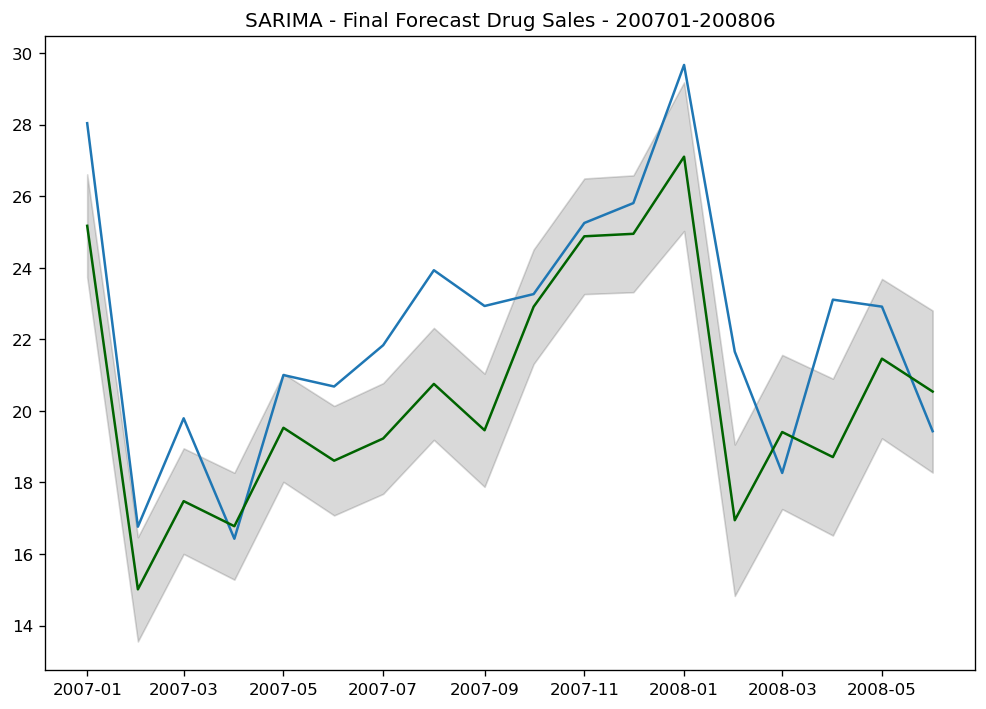

In [16]:
# Plot real x predito - Base teste
plt.plot(test)
plt.plot(fitted_series, color='darkgreen')
plt.fill_between(lower_series.index, 
                 lower_series, 
                 upper_series, 
                 color='k', alpha=.15)

plt.title("SARIMA - Final Forecast Drug Sales - 200701-200806")
plt.show()

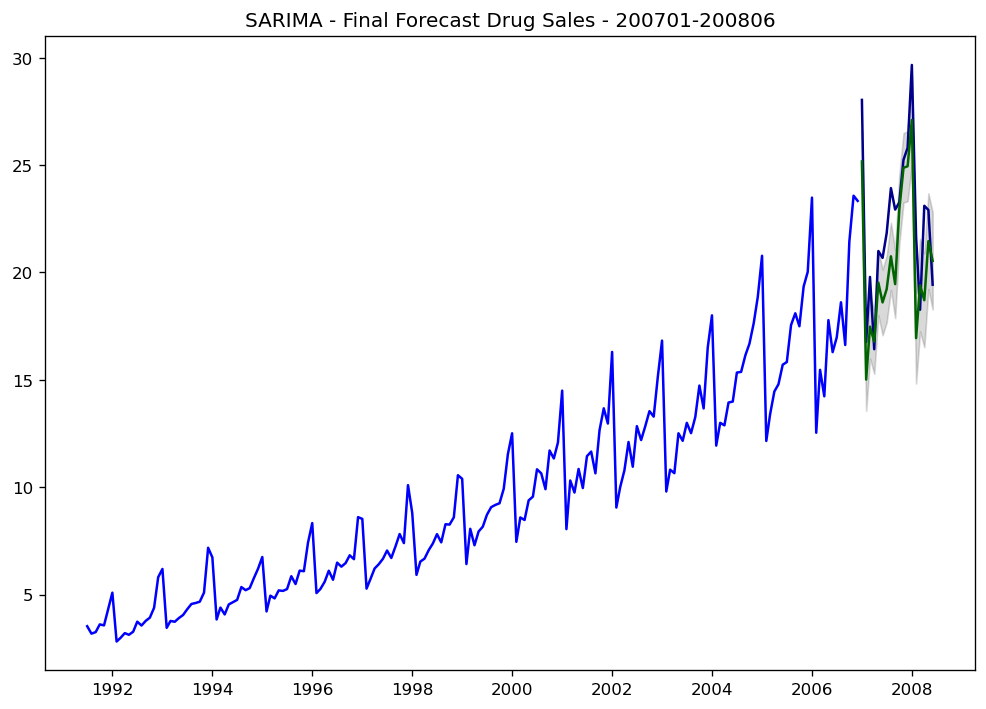

In [17]:
# Plot real x predito - Base train + teste
plt.plot(train.value, color='blue')
plt.plot(test, color='darkblue')
plt.plot(fitted_series, color='darkgreen')
plt.fill_between(lower_series.index, 
                 lower_series, 
                 upper_series, 
                 color='k', alpha=.15)

plt.title("SARIMA - Final Forecast Drug Sales - 200701-200806")
plt.show()

In [18]:
################################
# 3. AVALIAÇÃO NA BASE TESTE
# Accuracy metrics 
forecast_accuracy(fitted_series,test.value)

{'mape': 0.0921924937329962,
 'me': -1.7690494343496905,
 'mae': 2.0581261456490956,
 'mpe': -0.07653225615198328,
 'rmse': 2.4258994606112307,
 'corr': 0.8785577472379148}

Refrências:
    - https://medium.com/@josemarcialportilla/using-python-and-auto-arima-to-forecast-seasonal-time-series-90877adff03c